In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# Configurações 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Reproducibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
df = pd.read_csv('../data/raw/creditcard.csv')

# Estatísticas descritivas gerais
print(f"Shape: {df.shape}")
print(f"\n Estatísticas descritivas (Time, Amount, Class): ")
print(df[['Time', 'Amount', 'Class']].describe().round(2))

Shape: (284807, 31)

 Estatísticas descritivas (Time, Amount, Class): 
            Time     Amount      Class
count  284807.00  284807.00  284807.00
mean    94813.86      88.35       0.00
std     47488.15     250.12       0.04
min         0.00       0.00       0.00
25%     54201.50       5.60       0.00
50%     84692.00      22.00       0.00
75%    139320.50      77.16       0.00
max    172792.00   25691.16       1.00


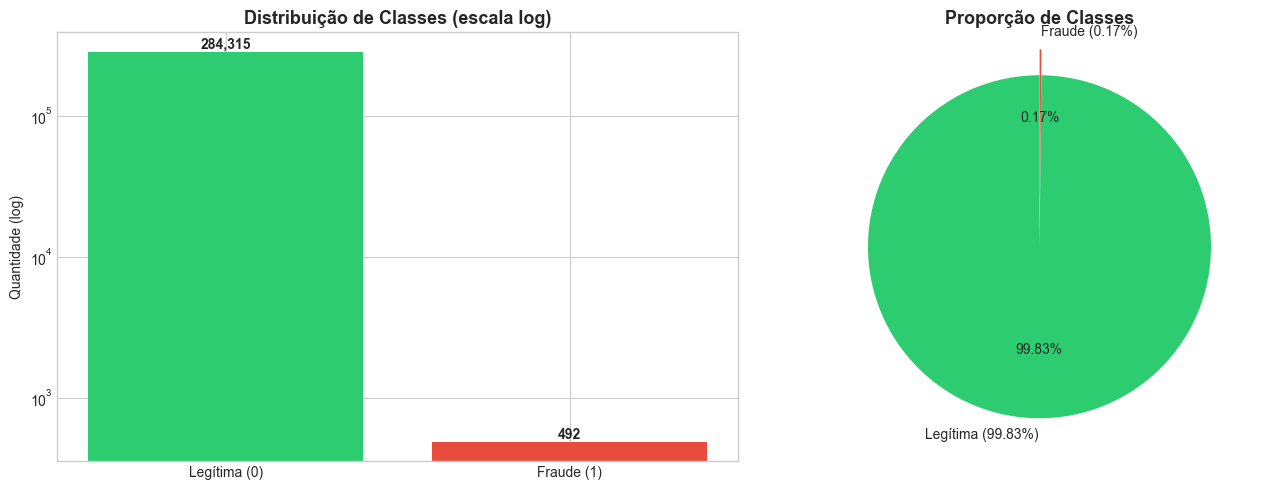

In [4]:
# Distribuição das classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# subplot 1: Contagem absoluta (escala log para enxergar fraudes)
class_counts = df['Class'].value_counts()
axes[0].bar(['Legítima (0)', 'Fraude (1)'], class_counts.values, color = ['#2ecc71', '#e74c3c'])
axes[0].set_yscale('log')
axes[0].set_title('Distribuição de Classes (escala log)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Quantidade (log)')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
# Subplot 2: Proporção percentual
class_pct = df['Class'].value_counts(normalize=True) * 100
axes[1].pie(class_pct.values, labels=['Legítima (99.83%)', 'Fraude (0.17%)'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.2f%%', startangle=90,
            explode=(0, 0.15))
axes[1].set_title('Proporção de Classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

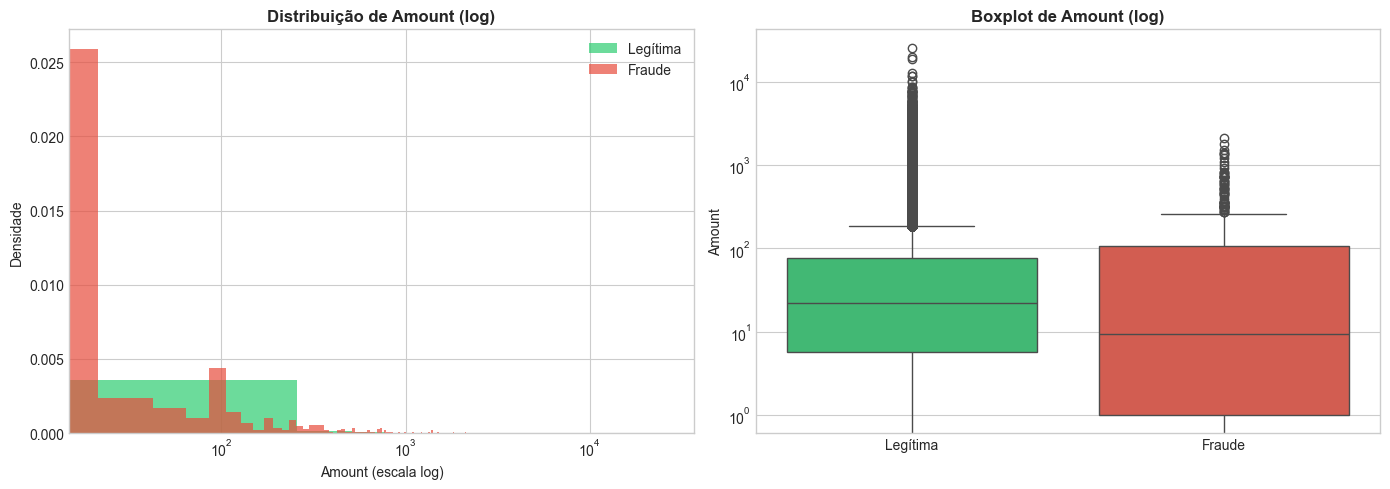


 Mediana Amount — Legítima: R$ 22.00
 Mediana Amount — Fraude: R$ 9.25


In [5]:
# Análise de Amount — Distribuições
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Distribuição geral (escala log)
axes[0].hist(df[df['Class'] == 0]['Amount'], bins=100, alpha=0.7,
             label='Legítima', color='#2ecc71', density=True)
axes[0].hist(df[df['Class'] == 1]['Amount'], bins=100, alpha=0.7,
             label='Fraude', color='#e74c3c', density=True)
axes[0].set_xscale('log')
axes[0].set_xlabel('Amount (escala log)')
axes[0].set_ylabel('Densidade')
axes[0].set_title('Distribuição de Amount (log)', fontweight='bold')
axes[0].legend()

# Subplot 2: Boxplot comparativo
df_plot = df.copy()
df_plot['Class_label'] = df_plot['Class'].map({0: 'Legítima', 1: 'Fraude'})
sns.boxplot(data=df_plot, x='Class_label', y='Amount', hue='Class_label', ax=axes[1],
            palette={'Legítima': '#2ecc71', 'Fraude': '#e74c3c'}, legend=False)
axes[1].set_yscale('log')
axes[1].set_title('Boxplot de Amount (log)', fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print(f"\n Mediana Amount — Legítima: R$ {df[df['Class']==0]['Amount'].median():.2f}")
print(f" Mediana Amount — Fraude: R$ {df[df['Class']==1]['Amount'].median():.2f}")

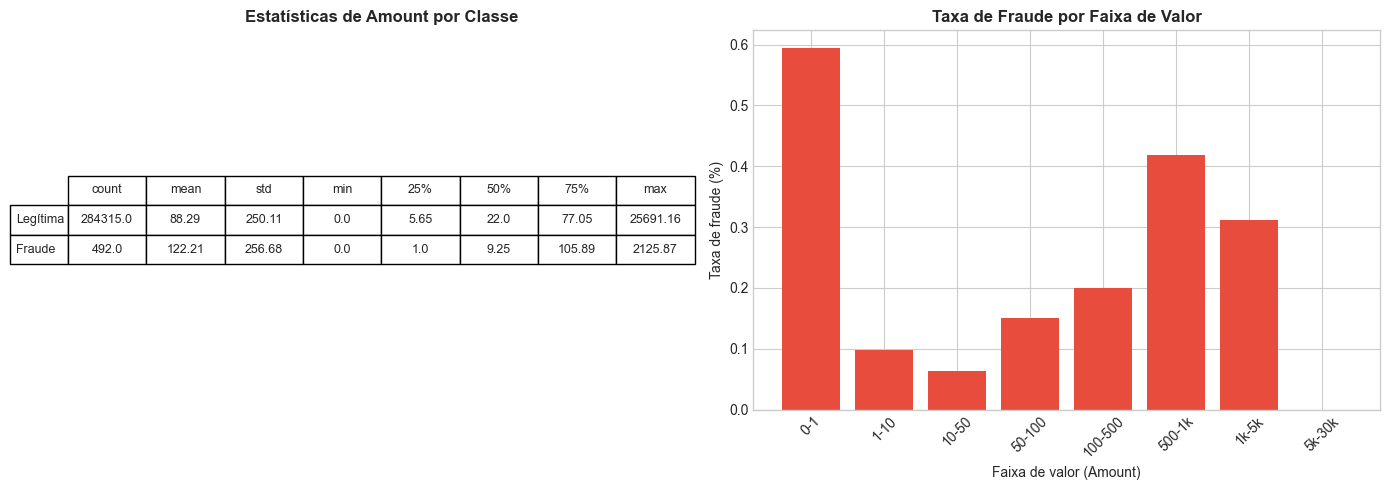

 Quantidade de fraudes com Amount = 0: 27
 Quantidade de legítimas com Amount = 0: 1798


In [6]:
# Análise de Amount — Estatísticas e Risco
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Estatísticas comparativas
stats_df = df.groupby('Class')['Amount'].describe().round(2)
stats_df.index = ['Legítima', 'Fraude']
axes[0].axis('off')
table = axes[0].table(cellText=stats_df.values,
                      rowLabels=stats_df.index,
                      colLabels=stats_df.columns,
                      loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)
axes[0].set_title('Estatísticas de Amount por Classe', fontweight='bold')

# Subplot 2: Faixa de valores - onde estão as fraudes?
bins = [0, 1, 10, 50, 100, 500, 1000, 5000, 30000]
labels = ['0-1', '1-10', '10-50', '50-100', '100-500', '500-1k', '1k-5k', '5k-30k']
df['Amount_bin'] = pd.cut(df['Amount'], bins=bins, labels=labels, include_lowest=True)
fraud_rate_by_bin = df.groupby('Amount_bin', observed=True)['Class'].mean() * 100
axes[1].bar(range(len(fraud_rate_by_bin)), fraud_rate_by_bin.values, color='#e74c3c')
axes[1].set_xticks(range(len(fraud_rate_by_bin)))
axes[1].set_xticklabels(fraud_rate_by_bin.index, rotation=45)
axes[1].set_xlabel('Faixa de valor (Amount)')
axes[1].set_ylabel('Taxa de fraude (%)')
axes[1].set_title('Taxa de Fraude por Faixa de Valor', fontweight='bold')

plt.tight_layout()
plt.show()

print(f" Quantidade de fraudes com Amount = 0: {((df['Class']==1) & (df['Amount']==0)).sum()}")
print(f" Quantidade de legítimas com Amount = 0: {((df['Class']==0) & (df['Amount']==0)).sum()}")

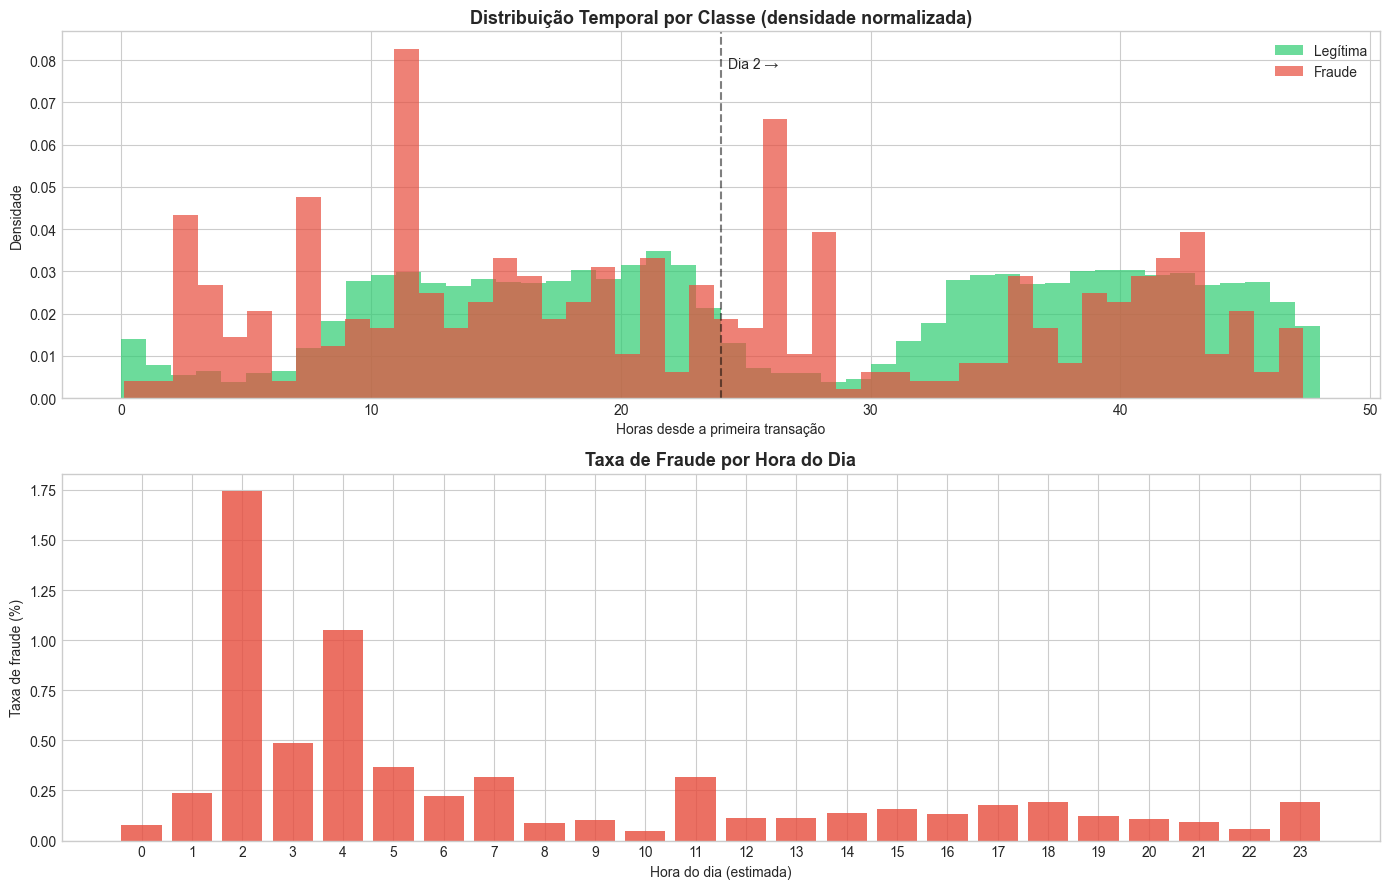


 Hora com maior taxa de fraude: 2h (1.743%)
 Hora com menor taxa de fraude: 10h (0.048%)


In [7]:
# Converter Time para HORAS ===
df['Hour'] = (df['Time'] / 3600) % 24  # Hora do dia (0-24)

# === DISTRIBUIÇÃO TEMPORAL ===
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Subplot 1: Distribuição absoluta de Time
axes[0].hist(df[df['Class'] == 0]['Time'] / 3600, bins=48, alpha=0.7, 
             label='Legítima', color='#2ecc71', density=True)
axes[0].hist(df[df['Class'] == 1]['Time'] / 3600, bins=48, alpha=0.7,
             label='Fraude', color='#e74c3c', density=True)
axes[0].set_xlabel('Horas desde a primeira transação')
axes[0].set_ylabel('Densidade')
axes[0].set_title('Distribuição Temporal por Classe (densidade normalizada)', 
                  fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].axvline(x=24, color='black', linestyle='--', alpha=0.5, label='Fim do dia 1')
axes[0].text(24.3, axes[0].get_ylim()[1]*0.9, 'Dia 2 →', fontsize=10)

# Subplot 2: Distribuição por hora do dia
hour_fraud = df[df['Class'] == 1].groupby(df[df['Class'] == 1]['Hour'].astype(int)).size()
hour_legit = df[df['Class'] == 0].groupby(df[df['Class'] == 0]['Hour'].astype(int)).size()
hour_fraud_pct = hour_fraud / hour_legit * 100  # taxa de fraude por hora

axes[1].bar(hour_fraud_pct.index, hour_fraud_pct.values, color='#e74c3c', alpha=0.8)
axes[1].set_xlabel('Hora do dia (estimada)')
axes[1].set_ylabel('Taxa de fraude (%)')
axes[1].set_title('Taxa de Fraude por Hora do Dia', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

print(f"\n Hora com maior taxa de fraude: {hour_fraud_pct.idxmax()}h ({hour_fraud_pct.max():.3f}%)")
print(f" Hora com menor taxa de fraude: {hour_fraud_pct.idxmin()}h ({hour_fraud_pct.min():.3f}%)")

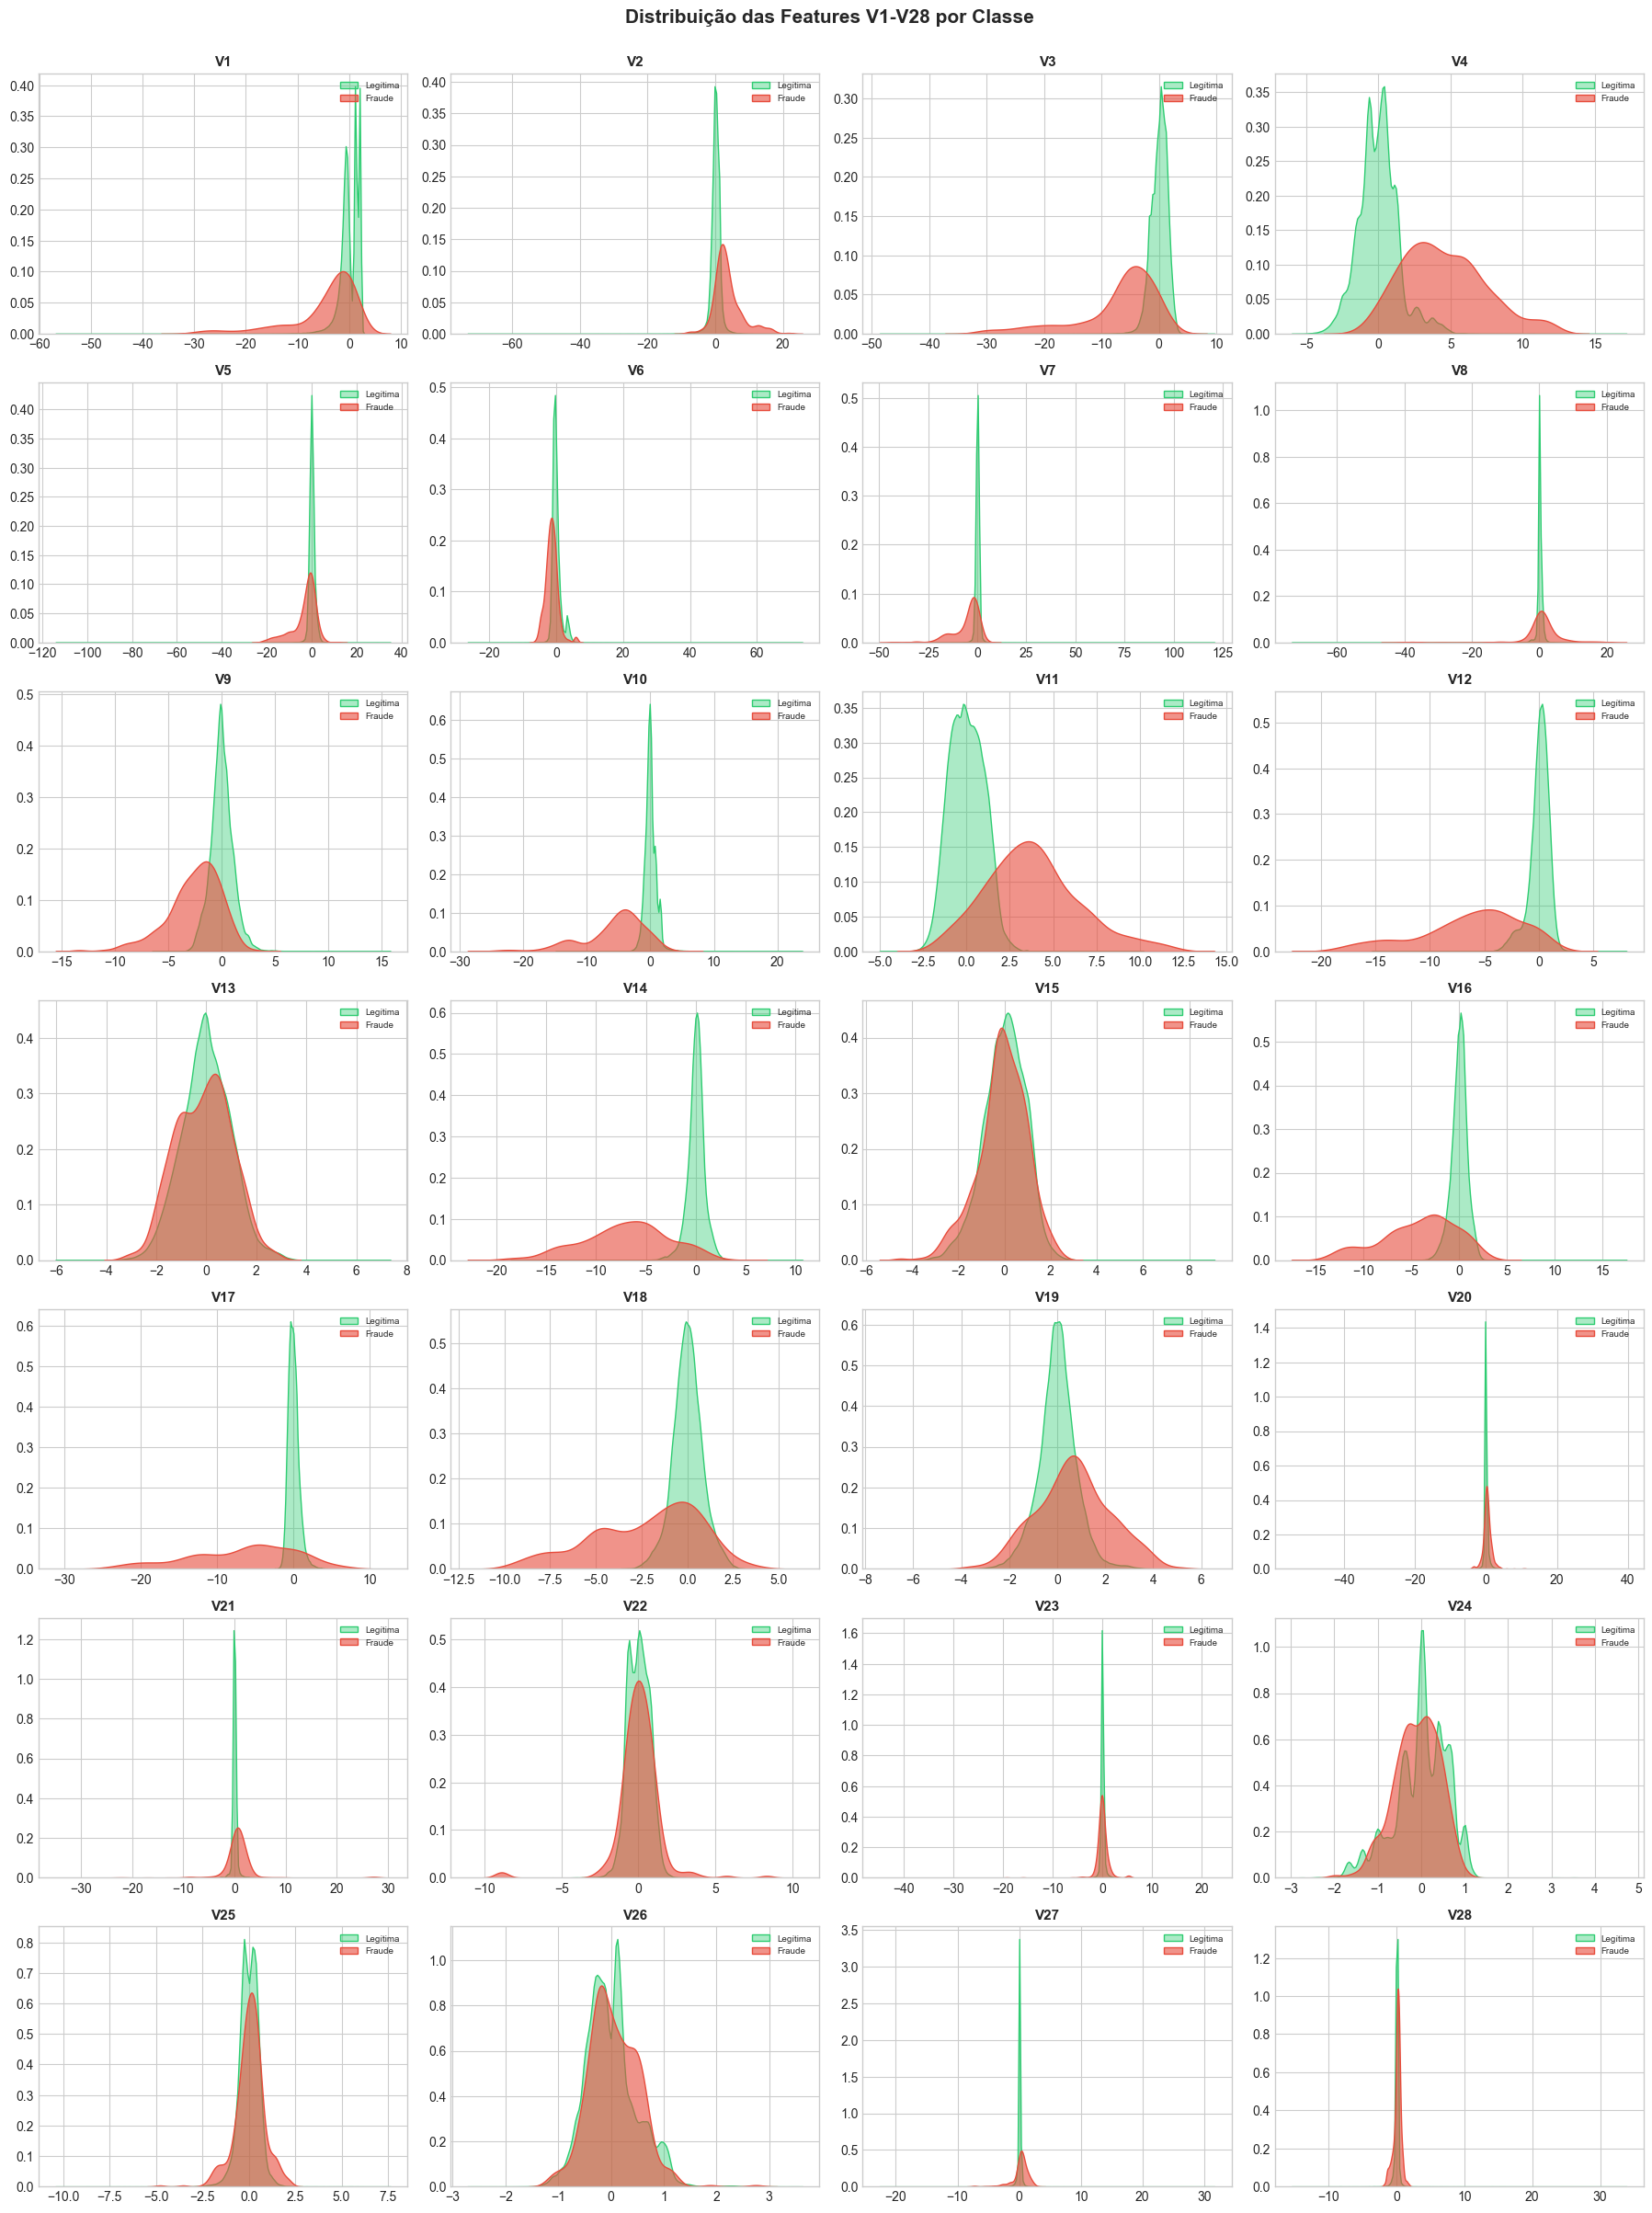

In [8]:
# GRID DE DISTRIBUIÇÕES V1-V28 POR CLASSE
v_features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(v_features):
    # KDE plot (Kernel Density Estimation) - mais limpo que histograma
    sns.kdeplot(data=df[df['Class'] == 0], x=col, ax=axes[i],
                color='#2ecc71', fill=True, alpha=0.4, label='Legítima', warn_singular=False)
    sns.kdeplot(data=df[df['Class'] == 1], x=col, ax=axes[i],
                color='#e74c3c', fill=True, alpha=0.6, label='Fraude', warn_singular=False)
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].legend(fontsize=7, loc='upper right')

plt.suptitle('Distribuição das Features V1-V28 por Classe', 
             fontsize=15, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

In [9]:
# RANKING DE PODER DISCRIMINATIVO (UNIVARIADO)
from scipy.stats import ks_2samp

results = []

for col in v_features + ['Amount', 'Time']:
    sample_legit = df[df['Class'] == 0][col]
    sample_fraud = df[df['Class'] == 1][col]
    
    # Teste KS (Kolmogorov-Smirnov): mede diferença entre distribuições
    ks_stat, ks_p = ks_2samp(sample_legit, sample_fraud)
    
    # Diferença de médias padronizada (Cohen's d aproximado)
    pooled_std = np.sqrt((sample_legit.var() + sample_fraud.var()) / 2)
    cohens_d = abs(sample_fraud.mean() - sample_legit.mean()) / pooled_std if pooled_std > 0 else 0
    
    results.append({
        'feature': col,
        'mean_legit': sample_legit.mean(),
        'mean_fraud': sample_fraud.mean(),
        'cohens_d': cohens_d,
        'ks_stat': ks_stat,
        'ks_pvalue': ks_p
    })

ranking = pd.DataFrame(results).sort_values('ks_stat', ascending=False).reset_index(drop=True)
ranking['ks_pvalue'] = ranking['ks_pvalue'].apply(lambda x: f'{x:.2e}')

print(" RANKING DE PODER DISCRIMINATIVO (univariado)")
print("=" * 65)
print(ranking.to_string(index=False))

 RANKING DE PODER DISCRIMINATIVO (univariado)
feature   mean_legit   mean_fraud  cohens_d  ks_stat ks_pvalue
    V14     0.012064    -6.971723  2.259076 0.842839  0.00e+00
    V10     0.009824    -5.676883  1.606058 0.804291  0.00e+00
    V12     0.010832    -6.259393  1.866983 0.783908 8.61e-321
     V4    -0.007860     4.542029  2.013335 0.766404 2.04e-302
    V11    -0.006576     3.800173  1.882183 0.756067 4.35e-292
    V17     0.011535    -6.665836  1.346956 0.745173 1.39e-281
     V3     0.012171    -7.033281  1.372580 0.703682 9.93e-245
    V16     0.007164    -4.139946  1.482429 0.686506 9.37e-231
     V7     0.009637    -5.568731  1.080309 0.660578 6.78e-211
     V2    -0.006271     3.623778  1.117825 0.633201 2.16e-191
     V9     0.004467    -2.581123  1.340457 0.576320 4.39e-155
    V21    -0.001235     0.713588  0.256894 0.518527 2.89e-123
    V18     0.003887    -2.246308  1.055673 0.503360 1.13e-115
     V6     0.002419    -1.397737  0.866567 0.486425 1.52e-107
     V1  

 Top 6 features: ['V14', 'V10', 'V12', 'V4', 'V11', 'V17']


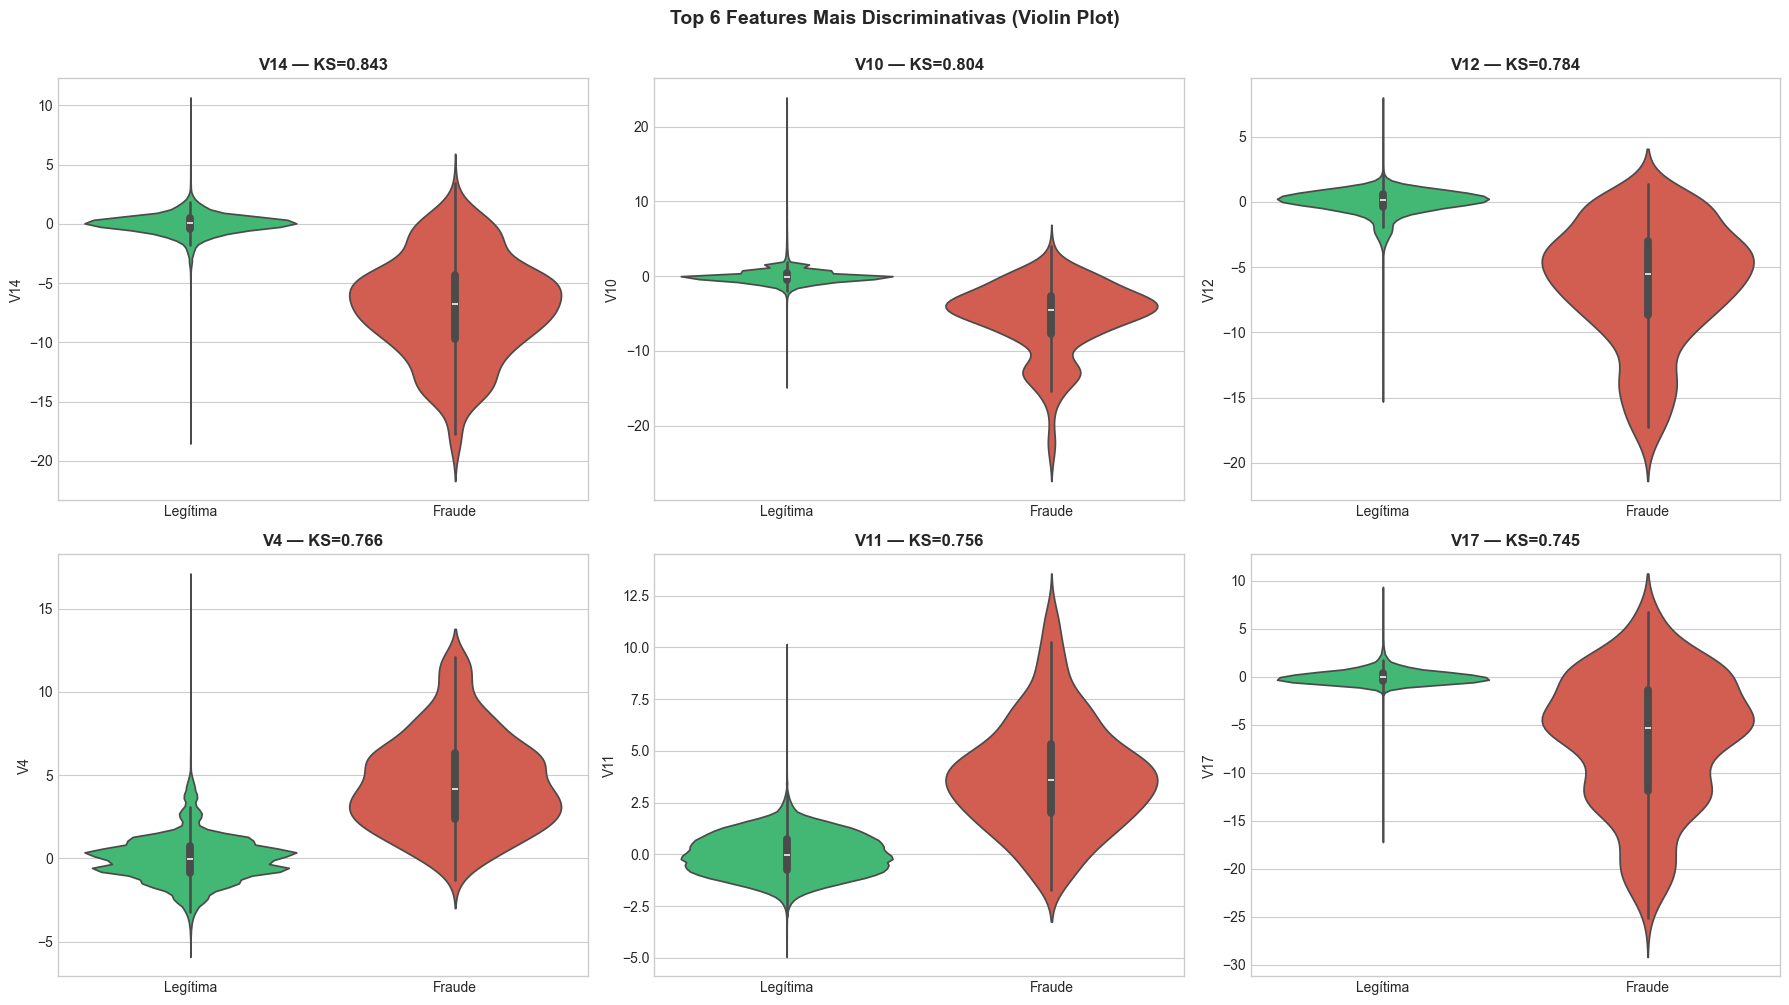

In [10]:
# TOP 6 FEATURES MAIS DISCRIMINATIVAS — ANÁLISE DETALHADA
top6 = ranking.head(6)['feature'].tolist()
print(f" Top 6 features: {top6}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top6):
    # Boxplot por classe
    df_plot = df[[col, 'Class']].copy()
    df_plot['Class_label'] = df_plot['Class'].map({0: 'Legítima', 1: 'Fraude'})
    
    sns.violinplot(data=df_plot, x='Class_label', y=col, hue='Class_label', ax=axes[i],
               palette={'Legítima': '#2ecc71', 'Fraude': '#e74c3c'}, legend=False)

    axes[i].set_title(f'{col} — KS={ranking[ranking["feature"]==col]["ks_stat"].iloc[0]:.3f}',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Top 6 Features Mais Discriminativas (Violin Plot)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

 Features potencialmente inúteis: ['V24', 'V13', 'V26', 'V25', 'V15', 'V22']


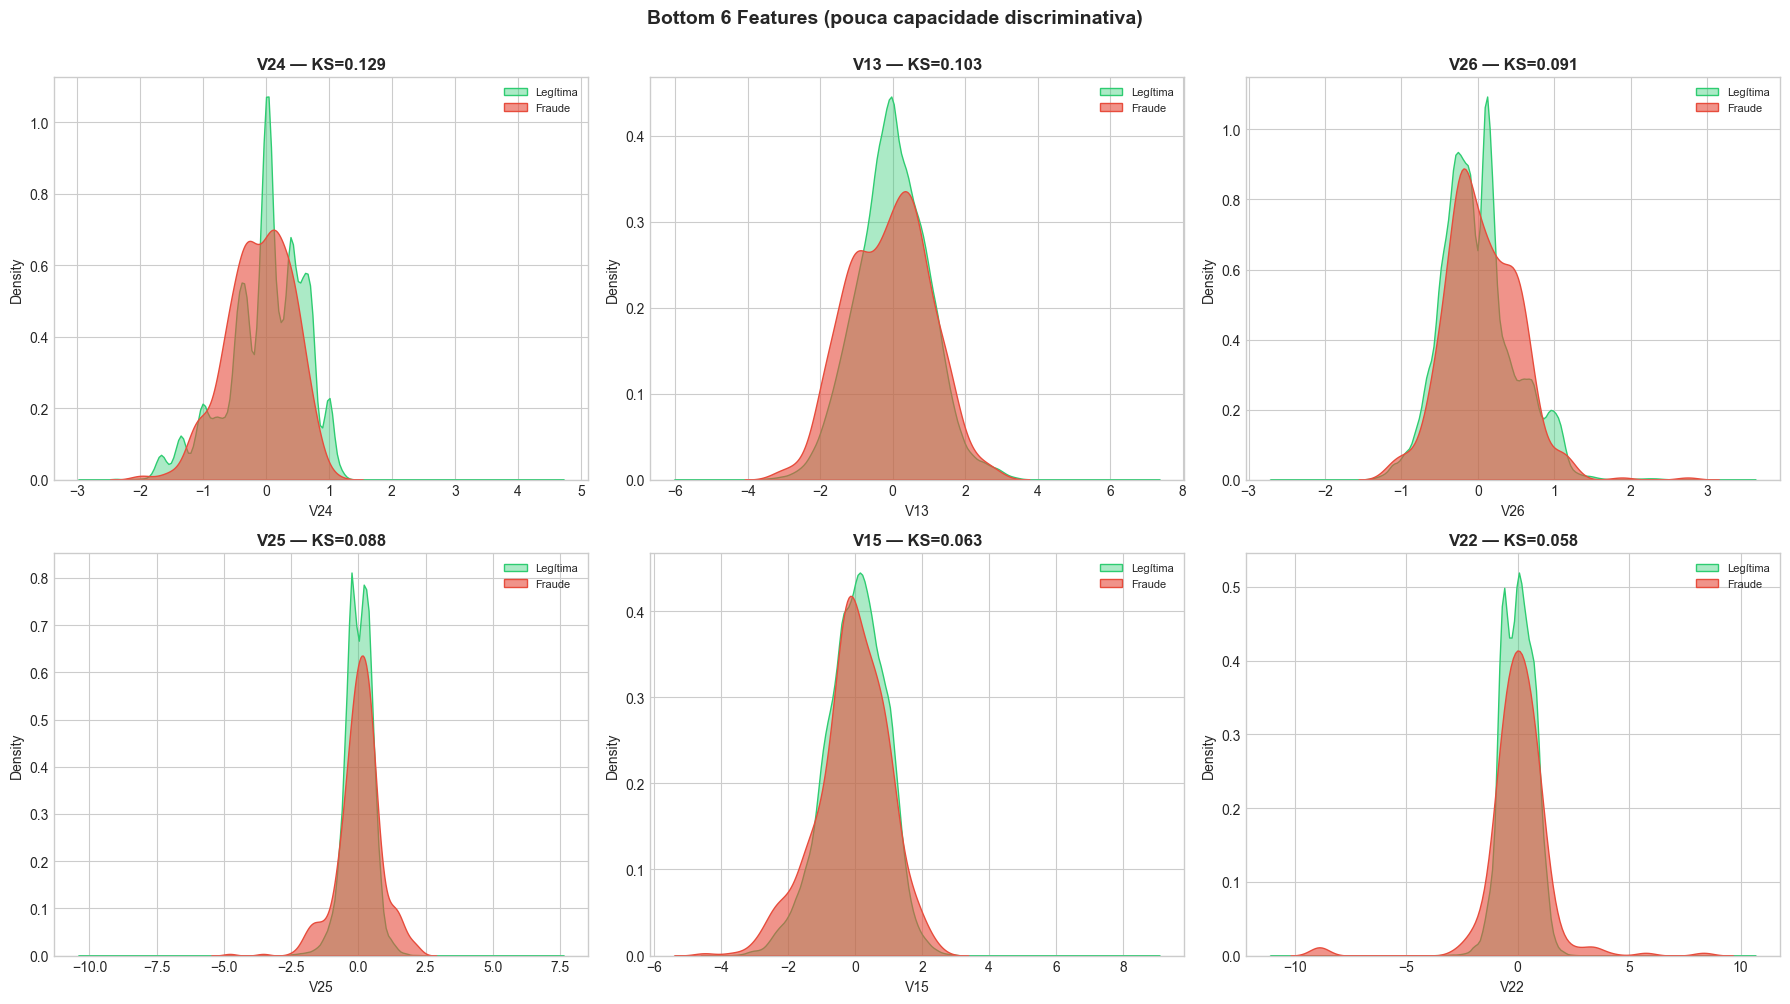

In [11]:
# BOTTOM 6 — FEATURES MENOS DISCRIMINATIVAS
bottom6 = ranking.tail(6)['feature'].tolist()
print(f" Features potencialmente inúteis: {bottom6}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(bottom6):
    sns.kdeplot(data=df[df['Class'] == 0], x=col, ax=axes[i],
                color='#2ecc71', fill=True, alpha=0.4, label='Legítima')
    sns.kdeplot(data=df[df['Class'] == 1], x=col, ax=axes[i],
                color='#e74c3c', fill=True, alpha=0.6, label='Fraude')
    axes[i].set_title(f'{col} — KS={ranking[ranking["feature"]==col]["ks_stat"].iloc[0]:.3f}',
                      fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Bottom 6 Features (pouca capacidade discriminativa)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 📝 Conclusões da Sub-etapa 4.2

### Features altamente preditivas (alto poder discriminativo)
- **V14, V12, V10, V17, V11, V4** → consistentemente as top em qualquer dataset de fraude PCA.
- KS > 0.5 indica distribuições muito distintas.

### Features pouco preditivas (candidatas à remoção em modelos lineares)
- **V13, V15, V22, V25, V26** → distribuições quase idênticas entre as classes.
- Em modelos não-lineares (XGBoost), podem ser mantidas (custo zero).

### Implicação para modelagem
- Logistic Regression com regularização L1 vai naturalmente zerar features inúteis.
- Tree-based models são robustos a features irrelevantes.
- **Não vamos remover features na Etapa 5** — deixaremos o modelo decidir.

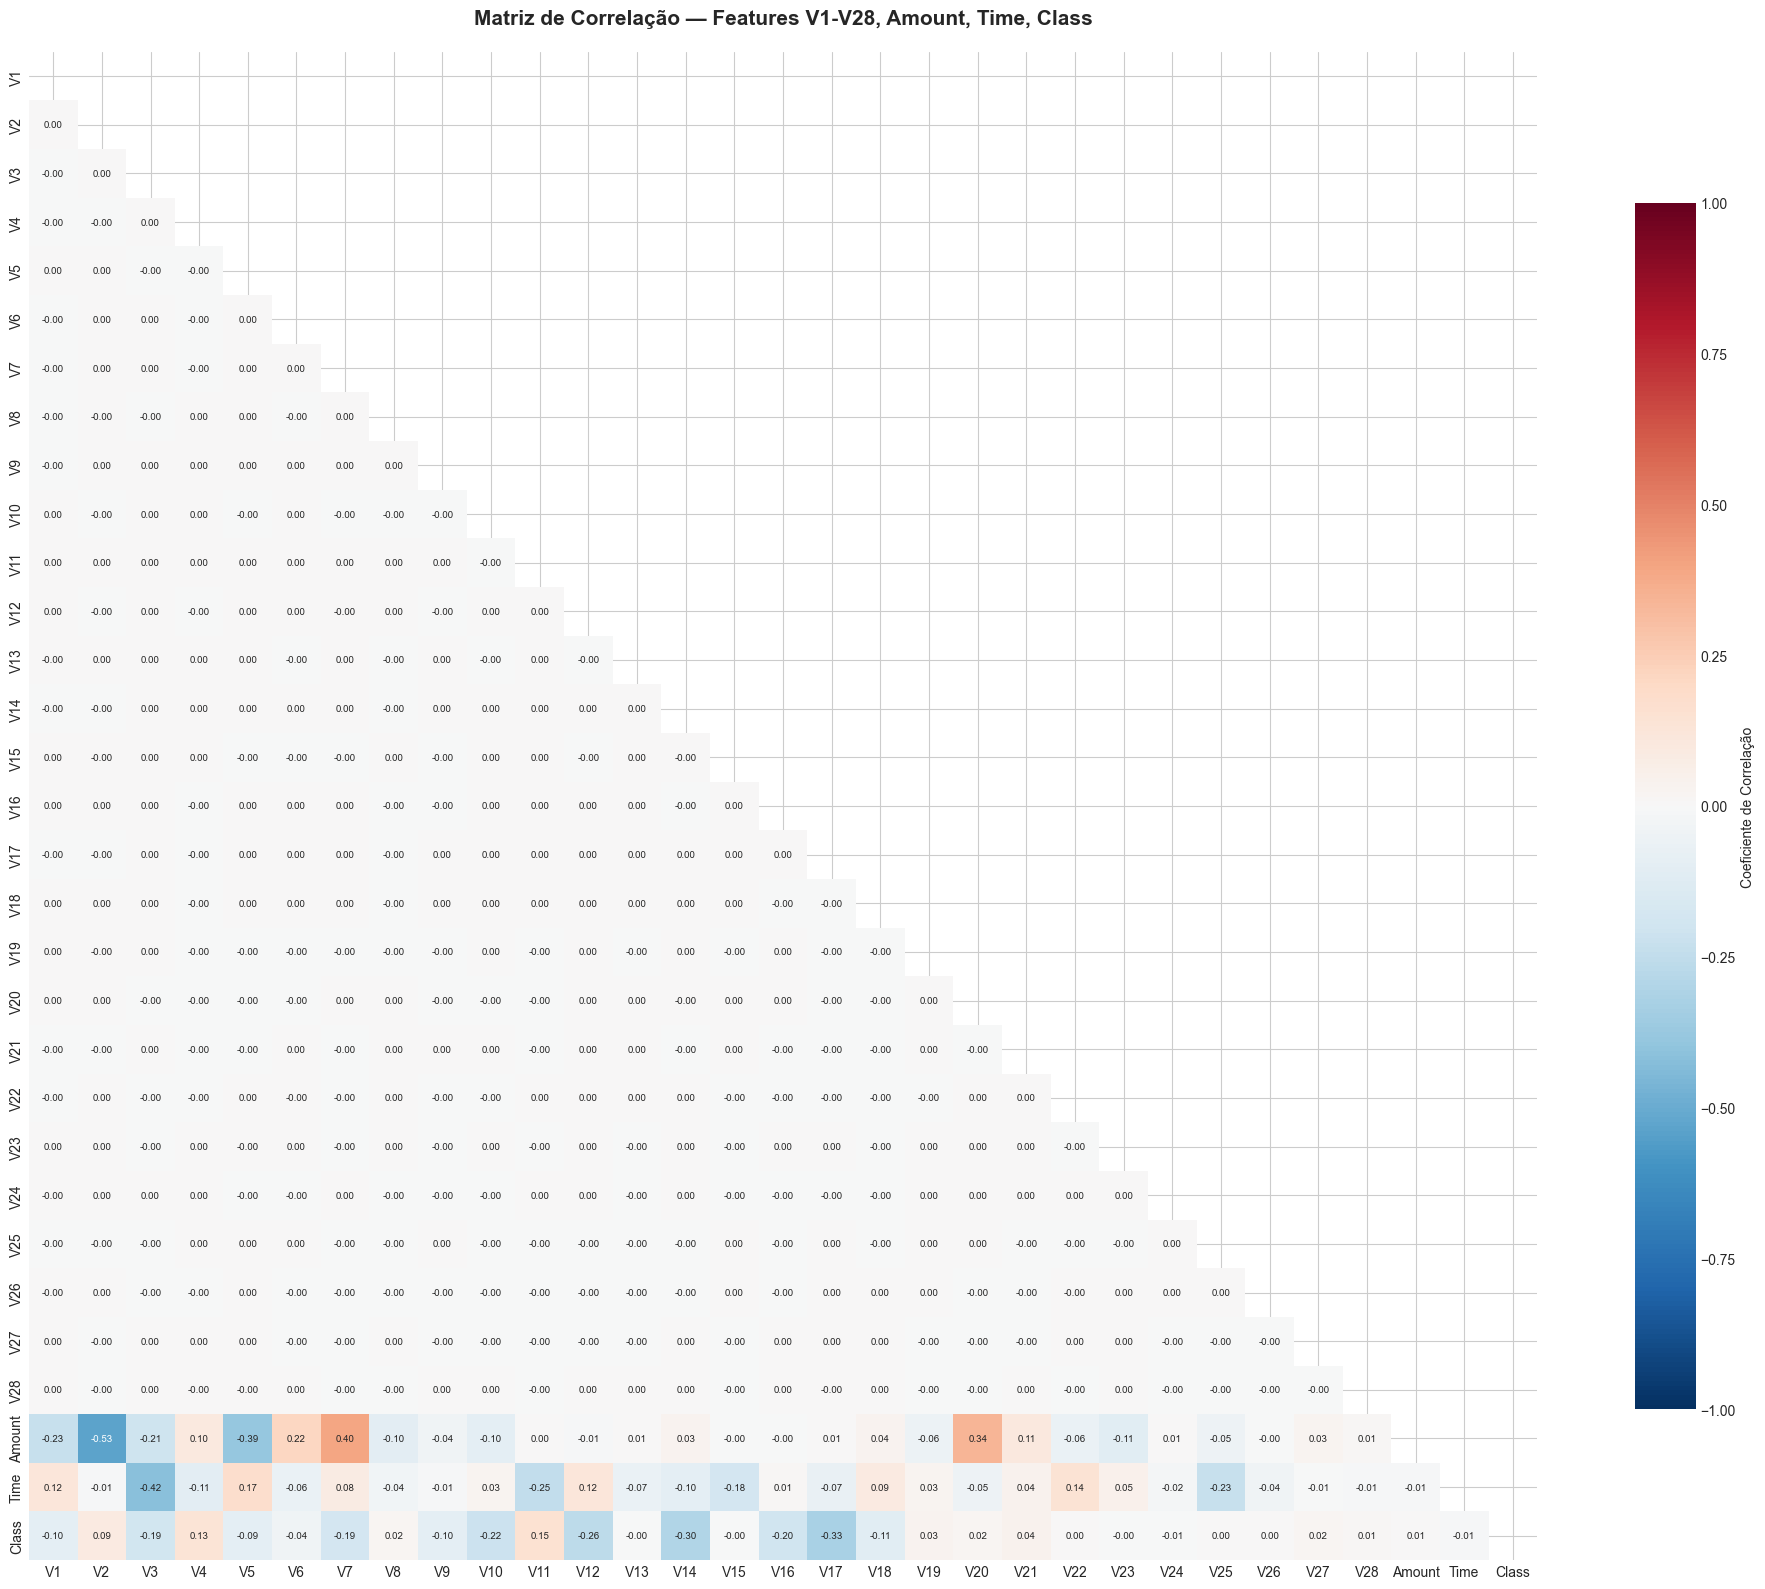

In [12]:
# HEATMAP DE CORRELAÇÕES
plt.figure(figsize=(20, 16))

# Selecionar apenas colunas numéricas relevantes
corr_cols = v_features + ['Amount', 'Time', 'Class']
corr_matrix = df[corr_cols].corr()

# Máscara para triângulo superior (evita redundância)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Correlação'},
            annot_kws={'size': 7})
plt.title('Matriz de Correlação — Features V1-V28, Amount, Time, Class',
          fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

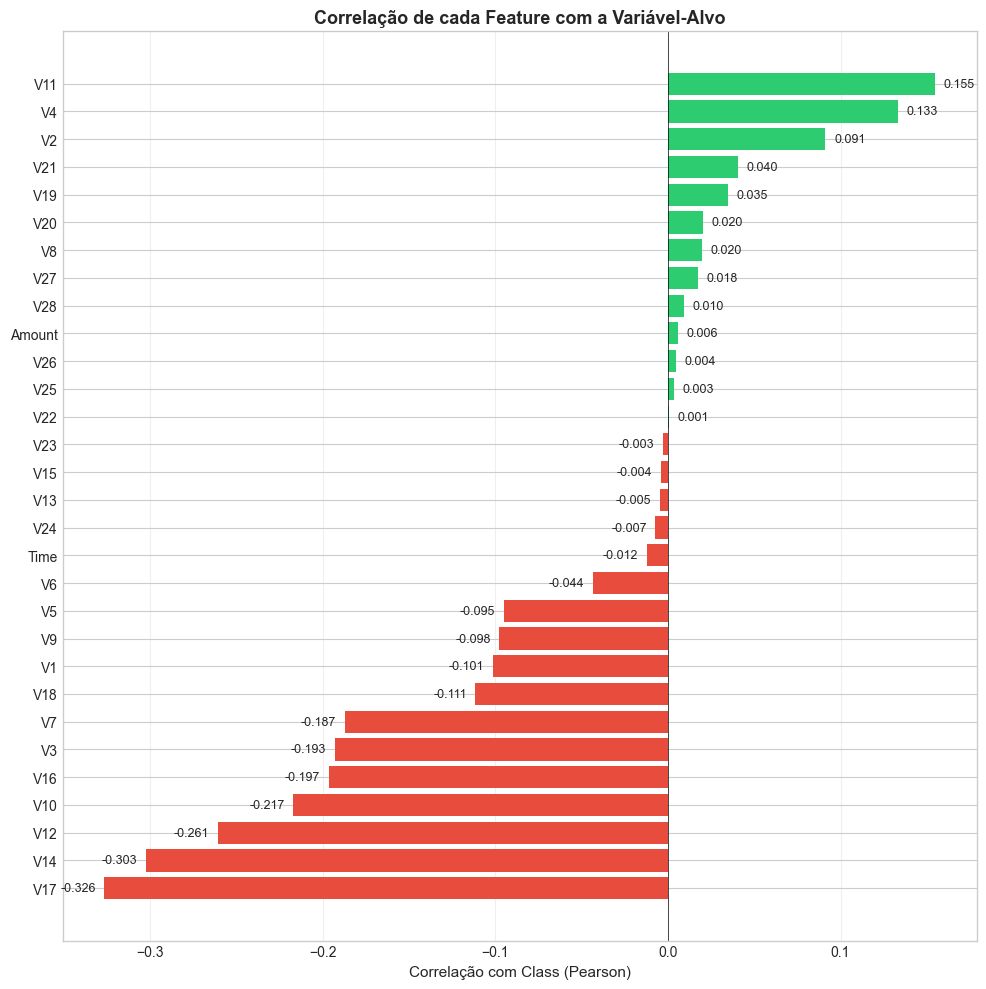

In [13]:
# CORRELAÇÃO COM TARGET 
target_corr = df[corr_cols].corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Correlação com Class (Pearson)', fontsize=11)
ax.set_title('Correlação de cada Feature com a Variável-Alvo', 
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Anotar valores
for i, v in enumerate(target_corr.values):
    ax.text(v + (0.005 if v >= 0 else -0.005), i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
print("\n Top 5 correlações negativas (fraudes têm valor BAIXO):")
print(target_corr.head(5).to_string())
print("\n Top 5 correlações positivas (fraudes têm valor ALTO):")
print(target_corr.tail(5).to_string())


 Top 5 correlações negativas (fraudes têm valor BAIXO):
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539

 Top 5 correlações positivas (fraudes têm valor ALTO):
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876


In [15]:
# CONFIRMAR QUE V's SÃO DESCORRELACIONADAS 
v_corr = df[v_features].corr()

# Tirar diagonal (correlação consigo mesma = 1)
np.fill_diagonal(v_corr.values, np.nan)

# Maior correlação absoluta entre V's diferentes
max_corr = v_corr.abs().max().max()
mean_corr = v_corr.abs().mean().mean()

print(f" Correlação MÁXIMA entre V's diferentes: {max_corr:.4f}")
print(f" Correlação MÉDIA absoluta entre V's: {mean_corr:.4f}")
print(f"\n Interpretação:")
if max_corr < 0.05:
    print("V's são fortemente descorrelacionadas — PCA confirmado.")
else:
    print("Existe alguma correlação residual.")

 Correlação MÁXIMA entre V's diferentes: 0.0000
 Correlação MÉDIA absoluta entre V's: 0.0000

 Interpretação:
V's são fortemente descorrelacionadas — PCA confirmado.


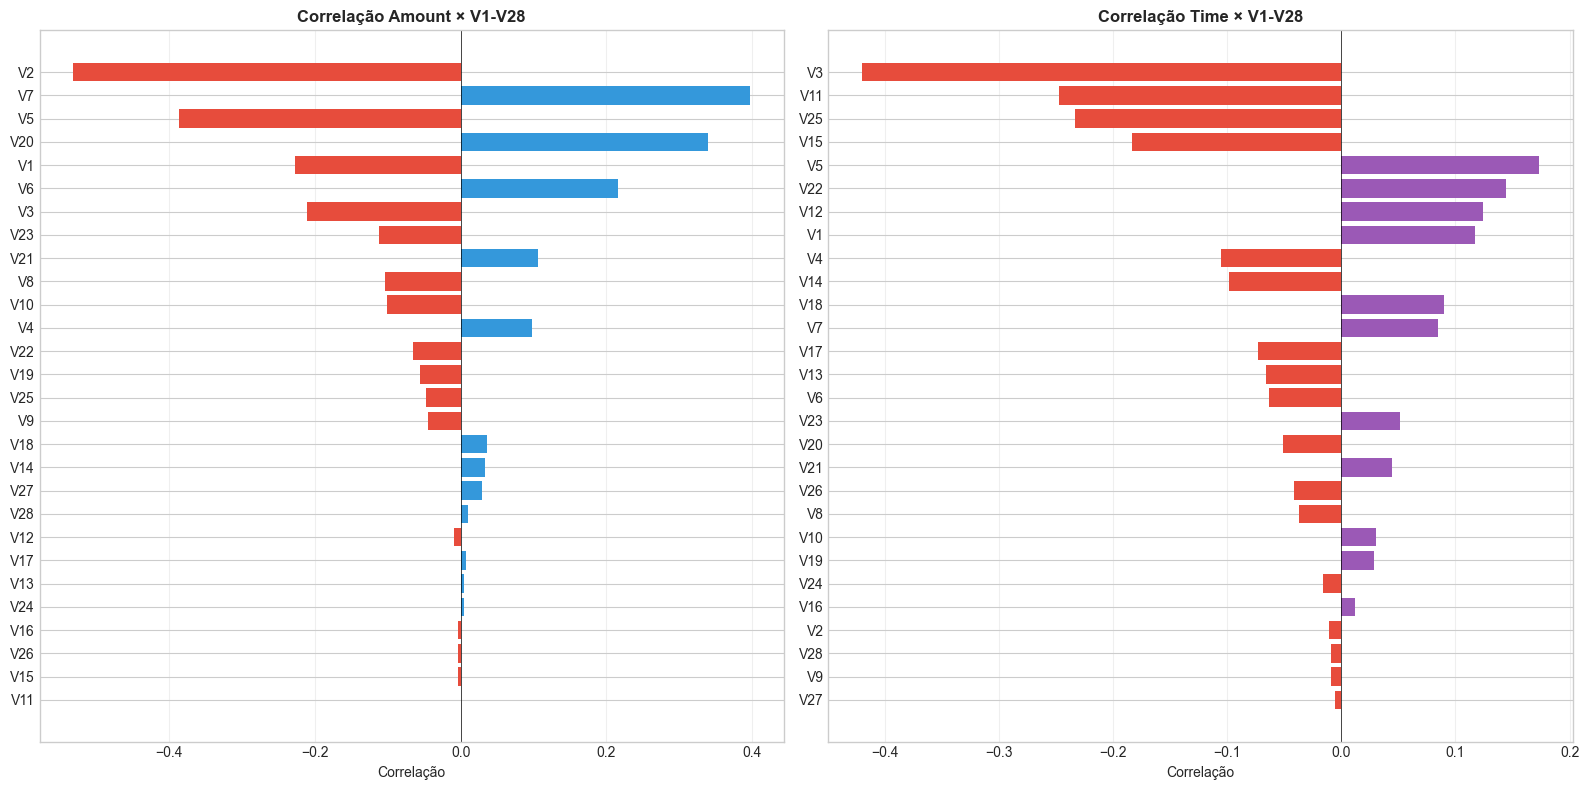

In [18]:
# CORRELAÇÕES DE AMOUNT E TIME COM V's 
amount_corr = df[v_features + ['Amount']].corr()['Amount'].drop('Amount').sort_values(key=abs, ascending=False)
time_corr = df[v_features + ['Time']].corr()['Time'].drop('Time').sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Amount
colors_amt = ['#e74c3c' if x < 0 else '#3498db' for x in amount_corr.values]
axes[0].barh(amount_corr.index[::-1], amount_corr.values[::-1], color=colors_amt[::-1])
axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[0].set_title('Correlação Amount × V1-V28', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Correlação')
axes[0].grid(axis='x', alpha=0.3)

# Time
colors_time = ['#e74c3c' if x < 0 else '#9b59b6' for x in time_corr.values]
axes[1].barh(time_corr.index[::-1], time_corr.values[::-1], color=colors_time[::-1])
axes[1].axvline(x=0, color='black', linewidth=0.5)
axes[1].set_title('Correlação Time × V1-V28', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Correlação')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
print("\n V's com maior correlação com Amount:")
print(amount_corr.head(5).to_string())
print("\n V's com maior correlação com Time:")
print(time_corr.head(5).to_string())


 V's com maior correlação com Amount:
V2    -0.531409
V7     0.397311
V5    -0.386356
V20    0.339403
V1    -0.227709

 V's com maior correlação com Time:
V3    -0.419618
V11   -0.247689
V25   -0.233083
V15   -0.183453
V5     0.173072


In [20]:
# DETECTAR PARES COM CORRELAÇÃO ALTA 
all_features = v_features + ['Amount', 'Time']
full_corr = df[all_features].corr().abs()

# Triângulo superior (evita duplicar pares)
upper = full_corr.where(np.triu(np.ones(full_corr.shape), k=1).astype(bool))

# Pares com correlação > 0.3
high_corr_pairs = []
for col in upper.columns:
    for idx in upper.index:
        val = upper.loc[idx, col]
        if pd.notna(val) and val > 0.3:
            high_corr_pairs.append((idx, col, val))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature_1', 'Feature_2', 'Correlação'])
high_corr_df = high_corr_df.sort_values('Correlação', ascending=False).reset_index(drop=True)

print(" Pares de features com correlação |r| > 0.3:")
if len(high_corr_df) > 0:
    print(high_corr_df.to_string(index=False))
else:
    print(" Nenhum par com correlação > 0.3 — sem problema de multicolinearidade.")

 Pares de features com correlação |r| > 0.3:
Feature_1 Feature_2  Correlação
       V2    Amount    0.531409
       V3      Time    0.419618
       V7    Amount    0.397311
       V5    Amount    0.386356
      V20    Amount    0.339403
